# Proyek Analisis Data: Bike Sharing Dataset

- **Nama:** Syeli Mutiatul Hilmy
- **Dataset:** Bike Sharing Dataset
- **Tujuan:** Menganalisis pola penyewaan sepeda berdasarkan faktor cuaca, musim, dan waktu untuk membantu pengambilan keputusan operasional.


## 1. Menentukan Pertanyaan Bisnis

Berikut pertanyaan bisnis yang digunakan dalam analisis ini.

1. **Bagaimana pengaruh kondisi cuaca terhadap rata-rata dan total jumlah penyewaan sepeda selama tahun 2011-2012?**  
   Pertanyaan ini spesifik pada faktor cuaca, terukur menggunakan `cnt`, relevan untuk strategi operasional, dapat menghasilkan rekomendasi, dan dibatasi pada periode 2011-2012.

2. **Pada jam berapa penyewaan sepeda paling tinggi pada hari kerja selama tahun 2011-2012?**  
   Pertanyaan ini spesifik pada pola jam peminjaman hari kerja, terukur menggunakan rata-rata `cnt` per jam, relevan untuk distribusi unit sepeda, dapat menjadi dasar action item, dan dibatasi pada periode 2011-2012.


## 2. Import Library

In [6]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 3. Data Wrangling

### 3.1 Gathering Data

Pada tahap ini, data harian dan data per jam dimuat ke dalam DataFrame.

In [8]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

display(day_df.head())
display(hour_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### 3.2 Assessing Data

Pada tahap ini dilakukan pemeriksaan struktur data, missing value, duplicate data, invalid value, dan indikasi outlier.

In [9]:
print("Informasi day_df:")
day_df.info()

print("\nInformasi hour_df:")
hour_df.info()


Informasi day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Informasi hour_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379

In [10]:
print("Jumlah missing value pada day_df:")
display(day_df.isna().sum())

print("Jumlah missing value pada hour_df:")
display(hour_df.isna().sum())

print("Duplicate day_df:", day_df.duplicated().sum())
print("Duplicate hour_df:", hour_df.duplicated().sum())


Jumlah missing value pada day_df:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Jumlah missing value pada hour_df:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Duplicate day_df: 0
Duplicate hour_df: 0


In [11]:
print("Statistik deskriptif day_df:")
display(day_df.describe(include="all"))

print("Statistik deskriptif hour_df:")
display(hour_df.describe(include="all"))


Statistik deskriptif day_df:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


Statistik deskriptif hour_df:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


In [12]:
# Mengecek invalid value pada kolom kategorikal yang memiliki rentang nilai tertentu
validations = {
    "season": [1, 2, 3, 4],
    "yr": [0, 1],
    "mnth": list(range(1, 13)),
    "holiday": [0, 1],
    "weekday": list(range(0, 7)),
    "workingday": [0, 1],
    "weathersit": [1, 2, 3, 4],
}

for col, valid_values in validations.items():
    invalid_day = sorted(set(day_df[col].unique()) - set(valid_values)) if col in day_df.columns else []
    invalid_hour = sorted(set(hour_df[col].unique()) - set(valid_values)) if col in hour_df.columns else []
    print(f"{col} | invalid day_df: {invalid_day} | invalid hour_df: {invalid_hour}")

invalid_hr = sorted(set(hour_df["hr"].unique()) - set(range(0, 24)))
print("hr | invalid hour_df:", invalid_hr)


season | invalid day_df: [] | invalid hour_df: []
yr | invalid day_df: [] | invalid hour_df: []
mnth | invalid day_df: [] | invalid hour_df: []
holiday | invalid day_df: [] | invalid hour_df: []
weekday | invalid day_df: [] | invalid hour_df: []
workingday | invalid day_df: [] | invalid hour_df: []
weathersit | invalid day_df: [] | invalid hour_df: []
hr | invalid hour_df: []


In [13]:
# Deteksi indikasi outlier menggunakan metode IQR pada kolom numerik utama
def count_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

numeric_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

outlier_summary = []
for col in numeric_cols:
    n_outlier, lower, upper = count_outliers_iqr(day_df, col)
    outlier_summary.append({
        "column": col,
        "outlier_count": n_outlier,
        "lower_bound": lower,
        "upper_bound": upper
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


,column,outlier_count,lower_bound,upper_bound
0,temp,0,-0.140416,1.132916
1,atemp,0,-0.068297,1.014741
2,hum,2,0.204687,1.045521
3,windspeed,13,-0.012447,0.380611
4,casual,44,-855.250000,2266.750000
5,registered,0,-922.250000,8195.750000
6,cnt,0,-1054.000000,10162.000000


#### Hasil Assessing Data

Berdasarkan pemeriksaan data, ditemukan beberapa hal berikut.

1. Tidak terdapat missing value pada `day_df` maupun `hour_df`.
2. Tidak terdapat duplicate data pada `day_df` maupun `hour_df`.
3. Kolom `dteday` masih bertipe object, sehingga perlu diubah menjadi tipe datetime.
4. Beberapa kolom kategorikal seperti `season`, `weathersit`, `yr`, dan `workingday` masih berbentuk angka sehingga perlu dibuatkan label agar lebih mudah dianalisis.
5. Terdapat indikasi outlier pada beberapa kolom numerik. Karena dataset ini merekam kejadian riil peminjaman sepeda, outlier tidak langsung dihapus. Nilai ekstrem tetap dipertahankan agar analisis tidak kehilangan informasi penting.


### 3.3 Cleaning Data

In [14]:
# Mengubah tipe data tanggal
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# Mapping label kategorikal
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

weather_map = {
    1: "Clear/Partly Cloudy",
    2: "Mist/Cloudy",
    3: "Light Snow/Rain",
    4: "Heavy Rain/Snow"
}

year_map = {
    0: 2011,
    1: 2012
}

workingday_map = {
    0: "Holiday/Weekend",
    1: "Working Day"
}

for df in [day_df, hour_df]:
    df["season_label"] = df["season"].map(season_map)
    df["weather_label"] = df["weathersit"].map(weather_map)
    df["year_label"] = df["yr"].map(year_map)
    df["workingday_label"] = df["workingday"].map(workingday_map)

display(day_df.head())
display(hour_df.head())


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label,year_label,workingday_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy,2011,Holiday/Weekend
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Spring,Mist/Cloudy,2011,Holiday/Weekend
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Spring,Clear/Partly Cloudy,2011,Working Day
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Spring,Clear/Partly Cloudy,2011,Working Day
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Spring,Clear/Partly Cloudy,2011,Working Day


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label,year_label,workingday_label
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Spring,Clear/Partly Cloudy,2011,Holiday/Weekend
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Spring,Clear/Partly Cloudy,2011,Holiday/Weekend
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Spring,Clear/Partly Cloudy,2011,Holiday/Weekend
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Spring,Clear/Partly Cloudy,2011,Holiday/Weekend
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Spring,Clear/Partly Cloudy,2011,Holiday/Weekend


In [16]:
day_df.to_csv("day_clean.csv", index=False)
hour_df.to_csv("hour_clean.csv", index=False)

print("Data bersih berhasil disimpan.")

Data bersih berhasil disimpan.


## 4. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik data sebelum menjawab pertanyaan bisnis.

### 4.1 EDA Univariate

In [17]:
display(day_df[["cnt", "casual", "registered", "temp", "atemp", "hum", "windspeed"]].describe())


,cnt,casual,registered,temp,atemp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,4504.348837,848.176471,3656.172367,0.495385,0.474354,0.627894,0.190486
std,1937.211452,686.622488,1560.256377,0.183051,0.162961,0.142429,0.077498
min,22.000000,2.000000,20.000000,0.059130,0.079070,0.000000,0.022392
25%,3152.000000,315.500000,2497.000000,0.337083,0.337842,0.520000,0.134950
50%,4548.000000,713.000000,3662.000000,0.498333,0.486733,0.626667,0.180975
75%,5956.000000,1096.000000,4776.500000,0.655417,0.608602,0.730209,0.233214
max,8714.000000,3410.000000,6946.000000,0.861667,0.840896,0.972500,0.507463


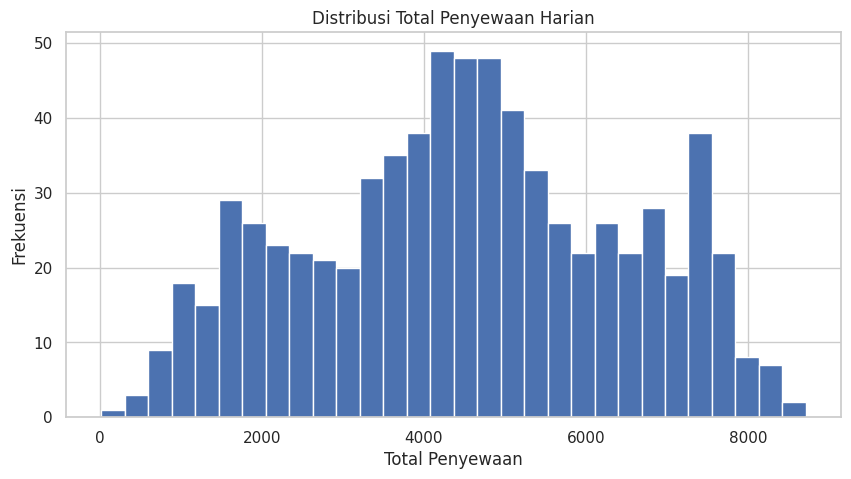

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(day_df["cnt"], bins=30)
plt.title("Distribusi Total Penyewaan Harian")
plt.xlabel("Total Penyewaan")
plt.ylabel("Frekuensi")
plt.show()


/tmp/ipykernel_495/1704753660.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


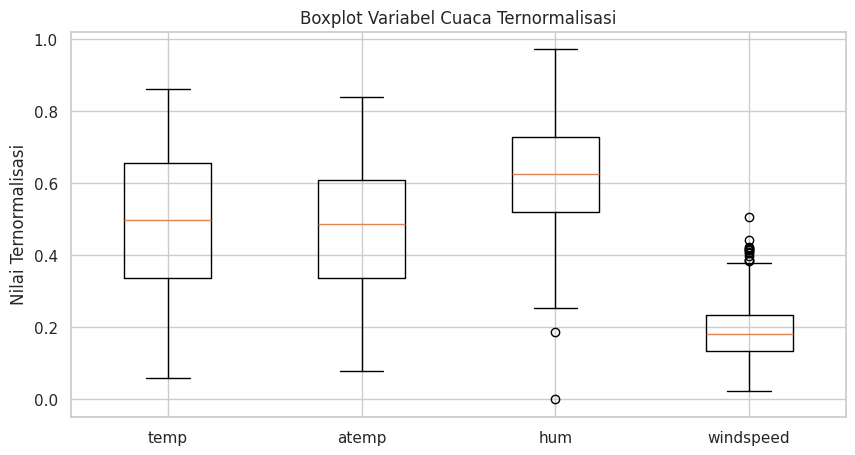

In [19]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    [day_df["temp"], day_df["atemp"], day_df["hum"], day_df["windspeed"]],
    labels=["temp", "atemp", "hum", "windspeed"]
)
plt.title("Boxplot Variabel Cuaca Ternormalisasi")
plt.ylabel("Nilai Ternormalisasi")
plt.show()


### 4.2 EDA Kategorikal dan Numerikal

In [20]:
season_summary = day_df.groupby("season_label").agg(
    total_rentals=("cnt", "sum"),
    avg_rentals=("cnt", "mean"),
    total_days=("instant", "count")
).sort_values("avg_rentals", ascending=False)

weather_summary = day_df.groupby("weather_label").agg(
    total_rentals=("cnt", "sum"),
    avg_rentals=("cnt", "mean"),
    total_days=("instant", "count")
).sort_values("avg_rentals", ascending=False)

display(season_summary)
display(weather_summary)


,total_rentals,avg_rentals,total_days
season_label,,,
Fall,1061129,5644.303191,188
Summer,918589,4992.331522,184
Winter,841613,4728.162921,178
Spring,471348,2604.132597,181


,total_rentals,avg_rentals,total_days
weather_label,,,
Clear/Partly Cloudy,2257952,4876.786177,463
Mist/Cloudy,996858,4035.862348,247
Light Snow/Rain,37869,1803.285714,21


In [21]:
monthly_summary = day_df.groupby(["year_label", "mnth"]).agg(
    total_rentals=("cnt", "sum"),
    avg_rentals=("cnt", "mean")
).reset_index()

display(monthly_summary.head())


,year_label,mnth,total_rentals,avg_rentals
0,2011,1,38189,1231.903226
1,2011,2,48215,1721.964286
2,2011,3,64045,2065.967742
3,2011,4,94870,3162.333333
4,2011,5,135821,4381.322581


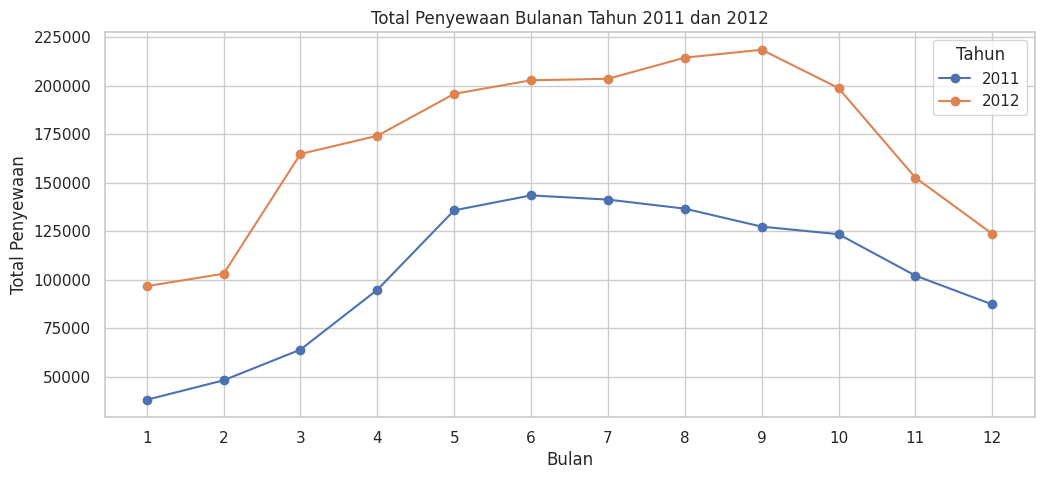

In [22]:
plt.figure(figsize=(12, 5))
for year in sorted(monthly_summary["year_label"].unique()):
    subset = monthly_summary[monthly_summary["year_label"] == year]
    plt.plot(subset["mnth"], subset["total_rentals"], marker="o", label=str(year))

plt.title("Total Penyewaan Bulanan Tahun 2011 dan 2012")
plt.xlabel("Bulan")
plt.ylabel("Total Penyewaan")
plt.xticks(range(1, 13))
plt.legend(title="Tahun")
plt.show()


### 4.3 EDA Multivariate

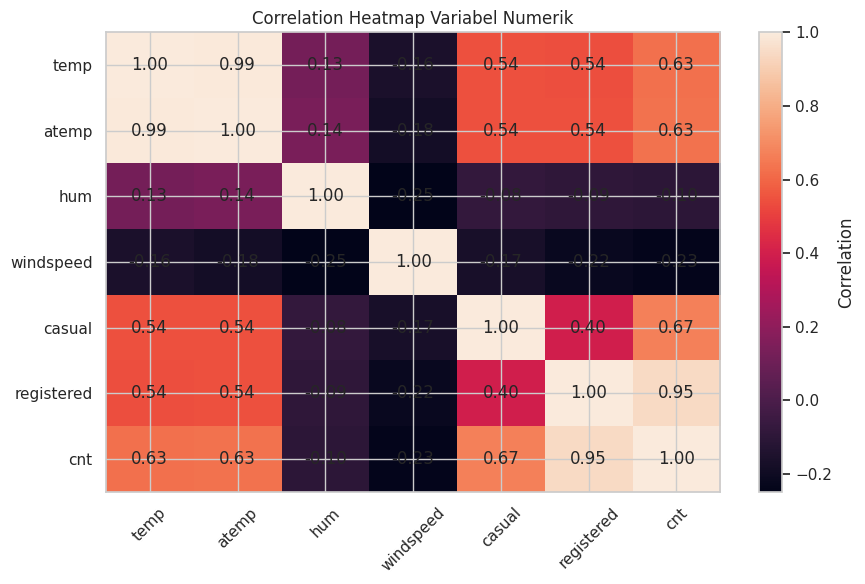

,cnt
cnt,1.000000
registered,0.945517
casual,0.672804
atemp,0.631066
temp,0.627494
hum,-0.100659
windspeed,-0.234545


In [23]:
corr_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]
corr_matrix = day_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap Variabel Numerik")
plt.tight_layout()
plt.show()

display(corr_matrix["cnt"].sort_values(ascending=False))


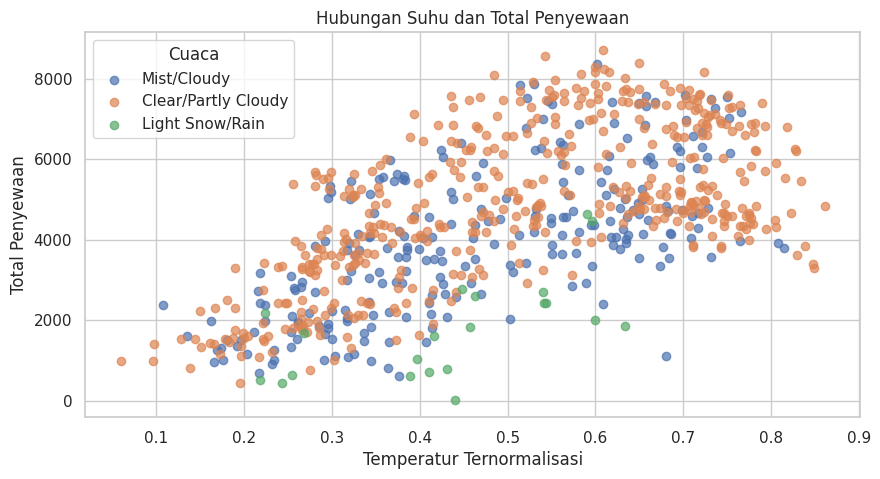

In [24]:
plt.figure(figsize=(10, 5))
for label in day_df["weather_label"].unique():
    subset = day_df[day_df["weather_label"] == label]
    plt.scatter(subset["temp"], subset["cnt"], label=label, alpha=0.7)

plt.title("Hubungan Suhu dan Total Penyewaan")
plt.xlabel("Temperatur Ternormalisasi")
plt.ylabel("Total Penyewaan")
plt.legend(title="Cuaca")
plt.show()


### 4.4 EDA untuk Menjawab Pertanyaan Bisnis

In [25]:
# Pertanyaan bisnis 1: pengaruh cuaca terhadap penyewaan
weather_analysis = day_df.groupby("weather_label").agg(
    avg_rentals=("cnt", "mean"),
    total_rentals=("cnt", "sum"),
    total_days=("instant", "count")
).sort_values("avg_rentals", ascending=False)

display(weather_analysis)


,avg_rentals,total_rentals,total_days
weather_label,,,
Clear/Partly Cloudy,4876.786177,2257952,463
Mist/Cloudy,4035.862348,996858,247
Light Snow/Rain,1803.285714,37869,21


In [26]:
# Pertanyaan bisnis 2: jam tersibuk pada hari kerja
workingday_hour = hour_df[hour_df["workingday"] == 1]

peak_hour_analysis = workingday_hour.groupby("hr").agg(
    avg_rentals=("cnt", "mean"),
    total_rentals=("cnt", "sum"),
    total_records=("instant", "count")
).reset_index().sort_values("avg_rentals", ascending=False)

display(peak_hour_analysis.head(10))


,hr,avg_rentals,total_rentals,total_records
17,17,525.290581,262120,499
18,18,492.226908,245129,498
8,8,477.006048,236595,496
19,19,348.401606,173504,498
16,16,293.122244,146268,499
7,7,290.612903,144144,496
20,20,249.718876,124360,498
9,9,241.518145,119793,496
15,15,201.331325,100263,498
12,12,200.820926,99808,497


## 5. Visualization & Explanatory Analysis

### 5.1 Visualisasi Pertanyaan Bisnis 1: Pengaruh Cuaca terhadap Penyewaan

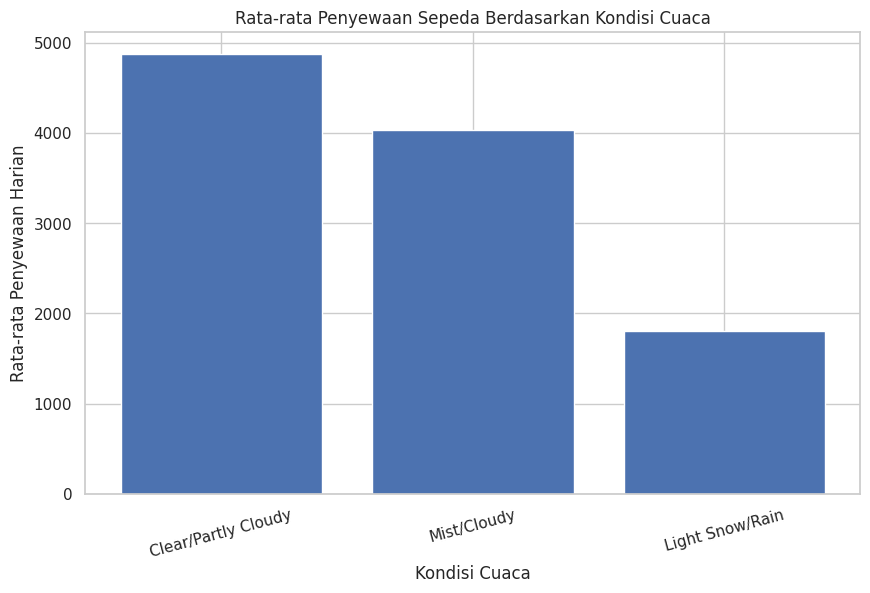

In [27]:
weather_plot = weather_analysis.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(weather_plot["weather_label"], weather_plot["avg_rentals"])
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan Harian")
plt.xticks(rotation=15)
plt.show()


### 5.2 Visualisasi Pertanyaan Bisnis 2: Jam Tersibuk pada Hari Kerja

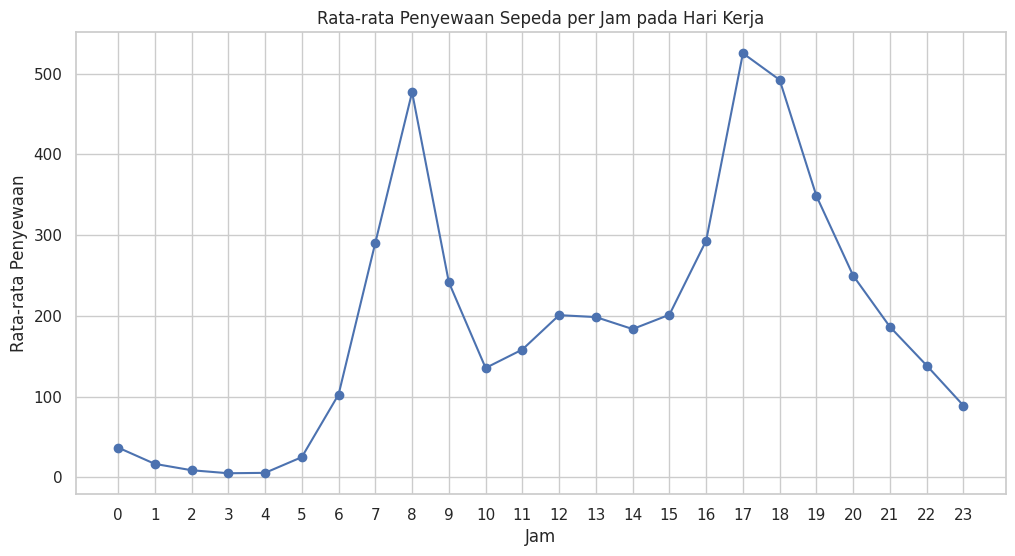

In [28]:
peak_hour_plot = workingday_hour.groupby("hr")["cnt"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(peak_hour_plot["hr"], peak_hour_plot["cnt"], marker="o")
plt.title("Rata-rata Penyewaan Sepeda per Jam pada Hari Kerja")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0, 24))
plt.show()


## 6. Conclusion & Recommendation

In [29]:
clear_avg = weather_analysis.loc["Clear/Partly Cloudy", "avg_rentals"]
mist_avg = weather_analysis.loc["Mist/Cloudy", "avg_rentals"]
rain_avg = weather_analysis.loc["Light Snow/Rain", "avg_rentals"]

peak_hour = peak_hour_analysis.iloc[0]["hr"]
peak_hour_avg = peak_hour_analysis.iloc[0]["avg_rentals"]
second_peak_hour = peak_hour_analysis.iloc[1]["hr"]
second_peak_avg = peak_hour_analysis.iloc[1]["avg_rentals"]
morning_peak_avg = peak_hour_analysis[peak_hour_analysis["hr"] == 8]["avg_rentals"].iloc[0]

print(f"Rata-rata penyewaan saat cuaca cerah: {clear_avg:.2f}")
print(f"Rata-rata penyewaan saat Mist/Cloudy: {mist_avg:.2f}")
print(f"Rata-rata penyewaan saat Light Snow/Rain: {rain_avg:.2f}")
print(f"Jam tersibuk hari kerja: {int(peak_hour)} dengan rata-rata {peak_hour_avg:.2f}")
print(f"Jam tersibuk kedua hari kerja: {int(second_peak_hour)} dengan rata-rata {second_peak_avg:.2f}")
print(f"Rata-rata jam 08.00 hari kerja: {morning_peak_avg:.2f}")


Rata-rata penyewaan saat cuaca cerah: 4876.79
Rata-rata penyewaan saat Mist/Cloudy: 4035.86
Rata-rata penyewaan saat Light Snow/Rain: 1803.29
Jam tersibuk hari kerja: 17 dengan rata-rata 525.29
Jam tersibuk kedua hari kerja: 18 dengan rata-rata 492.23
Rata-rata jam 08.00 hari kerja: 477.01


### Conclusion Pertanyaan Bisnis 1

Kondisi cuaca memiliki pengaruh yang jelas terhadap jumlah penyewaan sepeda. Berdasarkan data tahun 2011-2012, rata-rata penyewaan harian saat cuaca **Clear/Partly Cloudy** mencapai sekitar **4.876,79 penyewaan per hari**. Pada kondisi **Mist/Cloudy**, rata-ratanya turun menjadi sekitar **4.035,86 penyewaan per hari**. Penurunan paling besar terjadi pada kondisi **Light Snow/Rain**, dengan rata-rata hanya sekitar **1.803,29 penyewaan per hari**.

Secara tren, semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda. Hal ini menunjukkan bahwa pengguna lebih cenderung menyewa sepeda ketika kondisi cuaca nyaman dan menghindari penggunaan sepeda ketika hujan atau salju ringan.

**Actionable insight:** pengelola dapat meningkatkan ketersediaan sepeda dan petugas operasional saat cuaca cerah, serta menyiapkan strategi promosi atau layanan pendukung saat cuaca kurang baik agar permintaan tidak turun terlalu tajam.

### Conclusion Pertanyaan Bisnis 2

Pada hari kerja, pola penyewaan sepeda menunjukkan karakteristik penggunaan untuk aktivitas commuting. Jam dengan rata-rata penyewaan tertinggi adalah **17.00** dengan sekitar **525,29 penyewaan per jam**, diikuti oleh **18.00** dengan sekitar **492,23 penyewaan per jam**. Selain itu, jam **08.00** juga menunjukkan rata-rata tinggi yaitu sekitar **477,01 penyewaan per jam**.

Secara tren, permintaan meningkat pada pagi hari ketika pengguna berangkat kerja dan kembali meningkat lebih tinggi pada sore hari ketika pengguna pulang kerja. Pola ini mengindikasikan bahwa layanan bike sharing banyak dimanfaatkan sebagai transportasi harian.

**Actionable insight:** pengelola sebaiknya menambah stok sepeda dan memastikan redistribusi unit pada jam 07.00-09.00 serta 16.00-19.00, terutama di area perkantoran atau titik transit, agar pengguna tidak kehabisan sepeda pada jam sibuk.

### Rekomendasi Akhir

1. Tambahkan jumlah sepeda pada jam sibuk pagi dan sore hari.
2. Gunakan informasi cuaca sebagai dasar perencanaan operasional harian.
3. Buat strategi promosi pada cuaca kurang baik untuk menjaga tingkat penggunaan.
4. Prioritaskan redistribusi sepeda ke lokasi dengan permintaan tinggi pada hari kerja.
